<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/05_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **7. Variational Auto Encoder - deep learning**
- Unsupervised learning
- 비선형데이터의 차원축소, 노이즈제거 이미지 복원, 새로운 이미지 생성 알고리즘
<img src='https://blog.kakaocdn.net/dn/qLLF6/btqMOy3Wp7C/Cyi04XYJTecOhJwGlJ71e0/img.png' width=800>

- https://kvfrans.com/variational-autoencoders-explained/



### **A. Autoencoder**

<img src='https://kvfrans.com/content/images/2016/08/autoenc.jpg' width=600>

#### **[auto-encoders : Pytorch]("https://www.geeksforgeeks.org/deep-learning/implementing-an-autoencoder-in-pytorch/")**

#### **[auto-encoders : Keras, tensorflow]("https://www.geeksforgeeks.org/machine-learning/auto-encoders/")**

**Step 1: Importing Libraries**

We will be using PyTorch including the torch.nn module for building neural networks and torch.optim for optimization. For loading and preprocessing the MNIST dataset, we will use datasets and transforms from the torchvision package. Also we use Matplotlib for visualizing training progress and displaying images.




In [ ]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

**Step 2: Loading the Dataset**

Now we will load MNIST dataset containing 70,000 grayscale images of digits (0-9), each sized 28x28 pixels. We will convert images to tensors and create a data loader to fetch data in batches for training.




In [ ]:
tensor_transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True,
                         download=True, transform=tensor_transform)
loader = torch.utils.data.DataLoader(
    dataset=dataset, batch_size=32, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.67MB/s]


Step 3: Define the Autoencoder Model

In this step we are going to define our autoencoder. It consists of two components:

Encoder:
- Compresses the 784-pixel image into a smaller latent representation through fully connected layers with ReLU activations helps in reducing dimensions.

> 28*28 = 784 ==> 128 ==> 64 ==> 36 ==> 18 ==> 9

Decoder:
- Reconstructs the original image by expanding the latent vector back to the original size, ending with a Sigmoid activation to output pixel values between 0 and 1.

> 9 ==> 18 ==> 36 ==> 64 ==> 128 ==> 784 ==> 28*28 = 784




In [ ]:
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 36),
            nn.ReLU(),
            nn.Linear(36, 18),
            nn.ReLU(),
            nn.Linear(18, 9)
        )
        self.decoder = nn.Sequential(
            nn.Linear(9, 18),
            nn.ReLU(),
            nn.Linear(18, 36),
            nn.ReLU(),
            nn.Linear(36, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Step 4: Initializing Model

After defining the autoencoder, we create an instance of the model. We use Mean Squared Error (MSE) as the loss function since it measures how close the reconstructed images are to the original inputs.

For optimization, we use the Adam optimizer with a learning rate of 0.001 and weight decay of $10^{-8}$ which helps to prevent overfitting.






###**B. Variational Autoencoder**

<img src='https://kvfrans.com/content/images/2016/08/vae.jpg' width=600>


In [ ]:
model = AE()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

Step 5: Training the model and Plotting Training Loss

In this step the model undergoes training for 20 epochs. The training process updates the model's weights using backpropagation and optimization techniques. Loss values are recorded during each iteration and after training a loss plot is generated to assess the model’s performance over time.

Note: This snippet takes 15 to 20 mins to execute depending on the processor type. Initialize epoch = 1 for quick results. Use a GPU/TPU runtime for faster computations.




Epoch 1/5, Loss: 0.040107
Epoch 2/5, Loss: 0.035028
Epoch 3/5, Loss: 0.034541
Epoch 4/5, Loss: 0.029688
Epoch 5/5, Loss: 0.029430


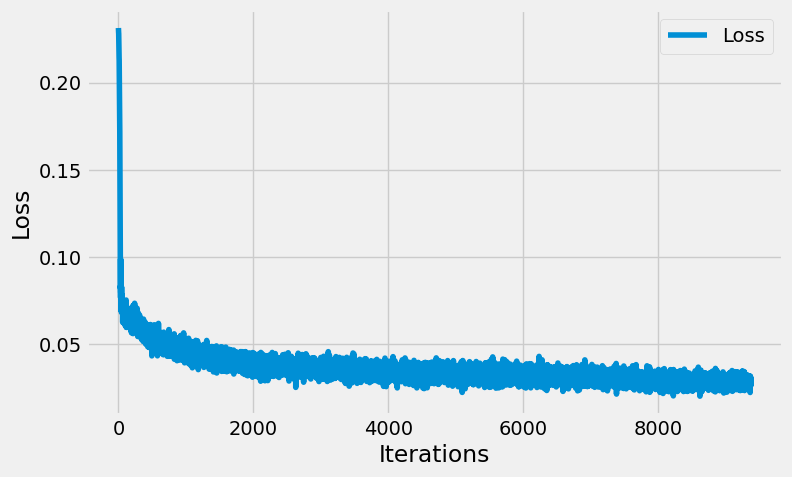

In [ ]:
epochs = 20
epochs = 5
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    for images, _ in loader:
        images = images.view(-1, 28 * 28).to(device)

        reconstructed = model(images)
        loss = loss_function(reconstructed, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    outputs.append((epoch, images, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

The loss curve in the image shows how the model's error decreases over training iterations. Initially the loss is high but quickly drops showing that the model is learning.



Step 6: Visualizing Original and Reconstructed Images

After training, it's important to see how well the autoencoder reconstructs the images. We take a batch of images and pass them through the trained model and display the original and reconstructed images side by side.




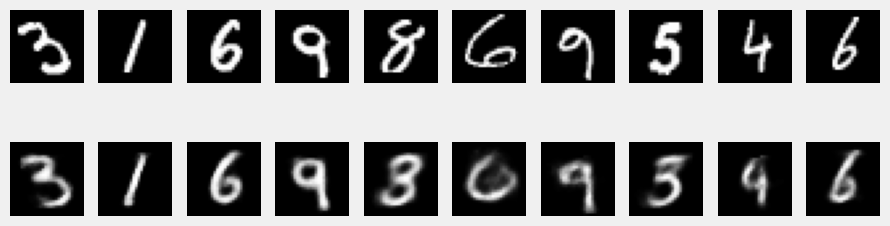

In [ ]:
model.eval()
dataiter = iter(loader)
images, _ = next(dataiter)

images = images.view(-1, 28 * 28).to(device)
reconstructed = model(images)

fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
plt.show()


###**C. Generative model using Variational Autoencoder**
<img src= 'https://miro.medium.com/max/1313/1*woWzbXU2bmshM1czEur72g.gif'>